# Song Popularity Prediction — Modeling

**Project 3 · Music Analytics · Laura Blanco**

Goal: predict whether a song lands in the **top 25% of popularity** (binary classification).
Building on the feature dataset, this notebook:
1. Trains and compares **Logistic Regression → Random Forest → LightGBM**.
2. Evaluates with **AUC-ROC** (target > 0.78) and F1.
3. Explains the model with **SHAP**.
4. Runs a **cold-start experiment** (predicting without artist history).
5. Audits **genre bias**: does the model work as well for regional genres as for global pop?

> The logic lives in `src/model.py`; here we run, visualize and interpret it.

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

import model as M

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
REPORTS = Path("../reports"); REPORTS.mkdir(exist_ok=True)

## 1. Train and compare models

A single hold-out split (80/20, stratified). The dataset is already deduplicated by
`track_id`, so a random split does not leak the same song across train/test. The
high-cardinality categoricals (`track_genre`, `artist_main`) are target-encoded
**inside** the pipeline (cross-fitted), so the target never leaks into the features.

In [2]:
results, fitted, (X_train, X_test, y_train, y_test) = M.train_and_evaluate()
results

Logistic Regression   AUC=0.902  F1=0.717
Random Forest         AUC=0.917  F1=0.733
LightGBM              AUC=0.919  F1=0.725


,model,auc_roc,f1
0,LightGBM,0.918737,0.724890
1,Random Forest,0.916782,0.732658
2,Logistic Regression,0.901842,0.717083


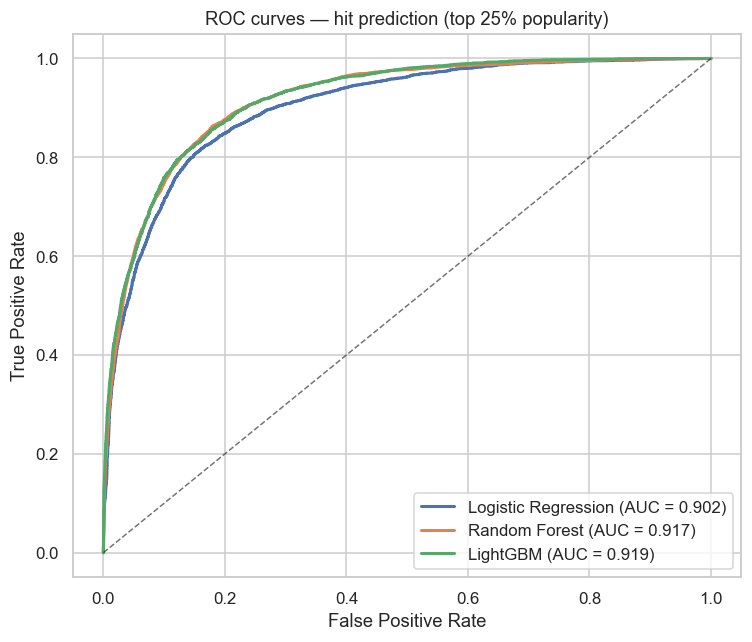

In [3]:
# ROC curves for the three models
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
ax.set(title="ROC curves — hit prediction (top 25% popularity)",
       xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(REPORTS / "fig8_roc_curves.png", bbox_inches="tight")
plt.show()

All three models clear the **AUC > 0.78** target comfortably. LightGBM and Random Forest
lead (~0.92); Logistic Regression is close behind (~0.90), which already hints that most of
the signal is captured by the target-encoded categoricals rather than complex interactions.

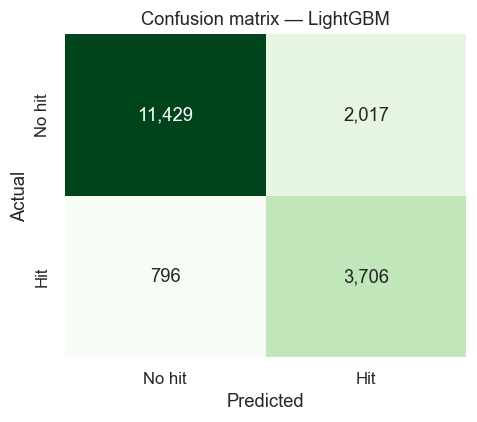

              precision    recall  f1-score   support

      No hit       0.93      0.85      0.89     13446
         Hit       0.65      0.82      0.72      4502

    accuracy                           0.84     17948
   macro avg       0.79      0.84      0.81     17948
weighted avg       0.86      0.84      0.85     17948



In [4]:
# Confusion matrix + classification report for the best model
best_name = results.iloc[0]["model"]
best = fitted[best_name]
proba = best.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens", cbar=False,
            xticklabels=["No hit", "Hit"], yticklabels=["No hit", "Hit"], ax=ax)
ax.set(title=f"Confusion matrix — {best_name}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.savefig(REPORTS / "fig9_confusion_matrix.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, pred, target_names=["No hit", "Hit"]))

## 2. Explainability with SHAP

Which features drive the predictions? We compute SHAP values on a sample of the test set
for the best model.

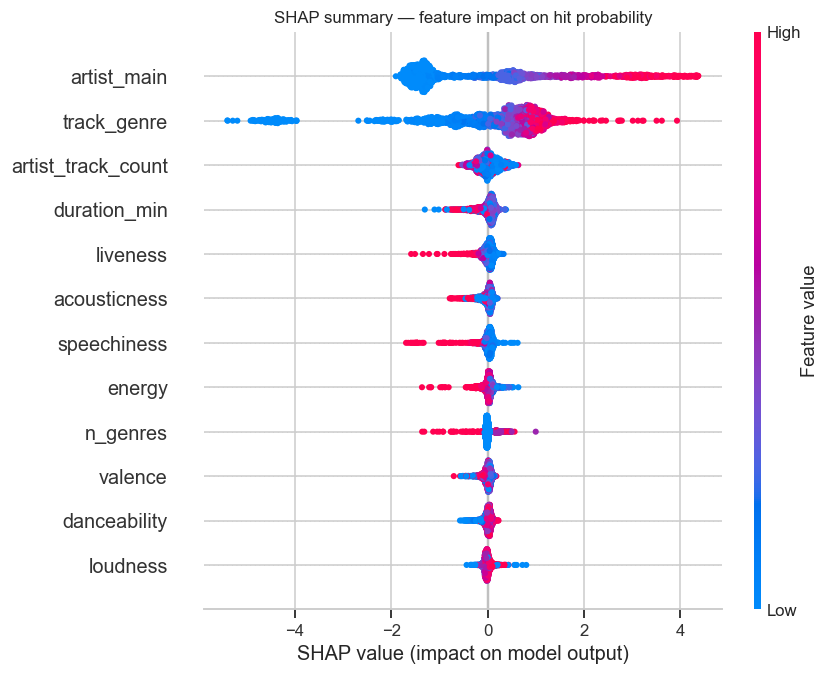

In [5]:
# Transform inputs through the pipeline preprocessor, then explain the classifier
prep = best.named_steps["prep"]
clf = best.named_steps["clf"]
feat_names = M.NUMERIC_FEATURES + M.CATEGORICAL_FEATURES

X_test_t = prep.transform(X_test)
sample = X_test_t[:2000]

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(sample)
if isinstance(shap_values, list):       # some versions return [class0, class1]
    shap_values = shap_values[1]

shap.summary_plot(shap_values, sample, feature_names=feat_names,
                  max_display=12, show=False)
plt.title("SHAP summary — feature impact on hit probability", fontsize=11)
plt.tight_layout()
plt.savefig(REPORTS / "fig10_shap_summary.png", bbox_inches="tight")
plt.show()

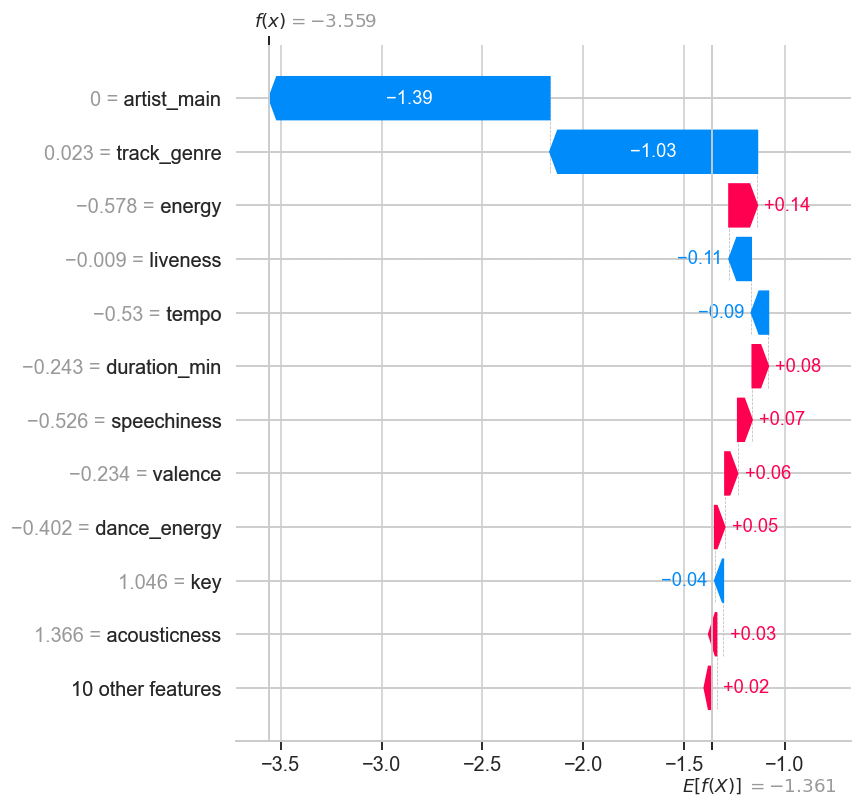

In [6]:
# Waterfall explanation for a single track
try:
    base = explainer.expected_value
    base = np.ravel(base)[-1]
    expl = shap.Explanation(values=shap_values[0], base_values=base,
                            data=sample[0], feature_names=feat_names)
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.tight_layout()
    plt.savefig(REPORTS / "fig11_shap_waterfall.png", bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Waterfall fallback (bar plot):", e)
    shap.summary_plot(shap_values, sample, feature_names=feat_names,
                      plot_type="bar", max_display=12, show=False)
    plt.savefig(REPORTS / "fig11_shap_waterfall.png", bbox_inches="tight")
    plt.show()

**Reading the SHAP plot:** the target-encoded `artist_main` and `track_genre` dominate
feature impact by a wide margin, far above any individual audio feature. This confirms the
EDA intuition: **popularity is mostly an attribute of the artist and the genre, not of the
sound of the track itself.** Audio features contribute, but at the margins.

This is an honest and important caveat for an A&R use case: the model is strong when it knows
the artist — but what about a brand-new artist with no track record?

## 3. Cold-start experiment — predicting without artist history

We retrain dropping `artist_main`, keeping only audio features + genre. This simulates
scoring a song by an **unknown artist** (the talent-discovery scenario).

In [7]:
cold_results, _, _ = M.train_and_evaluate(categorical=["track_genre"])
cold_results

Logistic Regression   AUC=0.828  F1=0.602
Random Forest         AUC=0.873  F1=0.656
LightGBM              AUC=0.873  F1=0.651


,model,auc_roc,f1
0,Random Forest,0.873387,0.656161
1,LightGBM,0.873259,0.651337
2,Logistic Regression,0.828223,0.601832


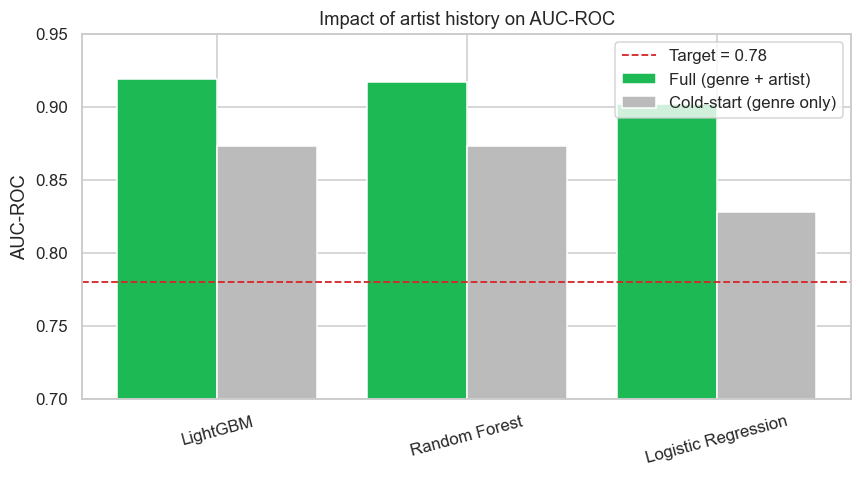

,model,AUC_full,AUC_coldstart
0,LightGBM,0.918737,0.873259
1,Random Forest,0.916782,0.873387
2,Logistic Regression,0.901842,0.828223


In [8]:
# Full vs cold-start AUC per model
comp = (results.rename(columns={"auc_roc": "AUC_full"})[["model", "AUC_full"]]
        .merge(cold_results.rename(columns={"auc_roc": "AUC_coldstart"})[["model", "AUC_coldstart"]],
               on="model"))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp["AUC_full"], 0.4, label="Full (genre + artist)", color="#1DB954")
ax.bar(x + 0.2, comp["AUC_coldstart"], 0.4, label="Cold-start (genre only)", color="#bbb")
ax.axhline(0.78, color="#d62728", ls="--", lw=1.2, label="Target = 0.78")
ax.set_xticks(x); ax.set_xticklabels(comp["model"], rotation=15)
ax.set(title="Impact of artist history on AUC-ROC", ylabel="AUC-ROC", ylim=(0.7, 0.95))
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "fig12_full_vs_coldstart.png", bbox_inches="tight")
plt.show()
comp

**Even without any artist information, the model still beats the target** (AUC ~0.87):
genre alone carries a lot of signal. The artist history adds ~0.04–0.05 AUC. The practical
takeaway: the tool is usable for new artists, but its edge shrinks — and decisions on unknown
acts should lean on the audio/genre signal, not on a (missing) artist prior.

## 4. Genre bias analysis — the differentiator

Does the model serve all genres equally? We compute **test AUC-ROC per genre** for the best
model. This matters for fairness and for any company betting on regional repertoire.

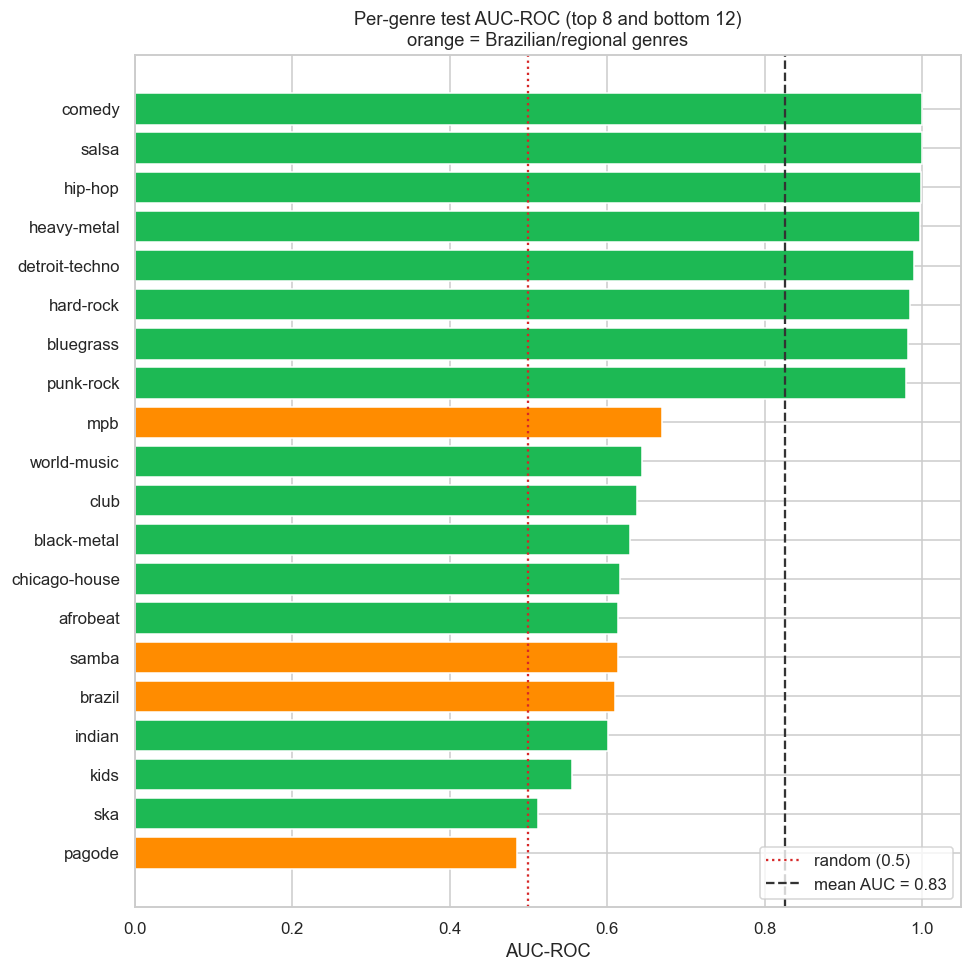

In [9]:
bias = M.genre_bias_analysis(best, X_test, y_test, None, min_samples=50)

# Brazilian / regional genres with low global reach
BRAZILIAN = {"brazil", "samba", "pagode", "mpb", "sertanejo", "forro"}
bias["highlight"] = bias["genre"].isin(BRAZILIAN)

show = pd.concat([bias.head(8), bias.tail(12)])
colors = ["#FF8C00" if h else "#1DB954" for h in show["highlight"]]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(show["genre"], show["auc_roc"], color=colors)
ax.axvline(0.5, color="#d62728", ls=":", label="random (0.5)")
ax.axvline(bias["auc_roc"].mean(), color="#333", ls="--",
           label=f"mean AUC = {bias['auc_roc'].mean():.2f}")
ax.set(title="Per-genre test AUC-ROC (top 8 and bottom 12)\norange = Brazilian/regional genres",
       xlabel="AUC-ROC")
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(REPORTS / "fig13_genre_bias.png", bbox_inches="tight")
plt.show()

In [10]:
# Quantify the gap: Brazilian vs globalized Latin vs the rest
BRAZILIAN = {"brazil", "samba", "pagode", "mpb", "sertanejo", "forro"}
LATIN_GLOBAL = {"salsa", "reggaeton", "latino", "spanish", "latin"}

br = bias[bias.genre.isin(BRAZILIAN)]["auc_roc"]
lg = bias[bias.genre.isin(LATIN_GLOBAL)]["auc_roc"]
other = bias[~bias.genre.isin(BRAZILIAN | LATIN_GLOBAL)]["auc_roc"]

print(f"Genres evaluated:            {len(bias)}")
print(f"Mean AUC — all genres:       {bias['auc_roc'].mean():.3f}")
print(f"Mean AUC — Brazilian/regional: {br.mean():.3f}  (n={len(br)})")
print(f"Mean AUC — globalized Latin:   {lg.mean():.3f}  (n={len(lg)})")
print(f"Mean AUC — everything else:    {other.mean():.3f}  (n={len(other)})")
print(f"\nWorst 5 genres:")
print(bias.tail(5)[["genre", "n_test", "hit_rate", "auc_roc"]].to_string(index=False))

Genres evaluated:            103
Mean AUC — all genres:       0.826
Mean AUC — Brazilian/regional: 0.625  (n=6)
Mean AUC — globalized Latin:   0.912  (n=5)
Mean AUC — everything else:    0.834  (n=92)

Worst 5 genres:
 genre  n_test  hit_rate  auc_roc
brazil     213  0.164319 0.609791
indian     203  0.458128 0.601271
  kids     197  0.005076 0.556122
   ska     160  0.012500 0.512658
pagode     189  0.195767 0.486309


### Key finding — the bias is specifically against Brazilian/regional genres

The worst-performing genres are almost all **Brazilian and regional** (`pagode`, `samba`,
`mpb`, `brazil`, `sertanejo`, `forro`) — averaging **AUC ≈ 0.61**, with `pagode` dropping
**below 0.5 (worse than random)**. Crucially, this is **not** a blanket "Latin music" problem:
**globalized Latin genres predict very well** — salsa, reggaeton, `spanish` and `latino` all
score 0.88–1.00. The dividing line is **global reach**, not language or region per se.

**Why this happens:** `popularity` is a *global* Spotify score. Reggaeton and salsa are
streamed worldwide, so their hit signal is well represented in training. Pagode, samba and
sertanejo are huge *inside Brazil* but carry low global popularity — the model never learns
their local notion of a hit, so it fails on exactly the repertoire a Brazilian label cares about.

**Business implication:** a company investing in regional Brazilian repertoire should **not**
trust a globally-trained popularity model off-the-shelf for A&R. It needs region-specific
targets (e.g. local chart performance) — exactly the nuance that differentiates analytics
built with LATAM context in mind.

## 5. Limitations and conclusions

**Achieved:**
- LightGBM **AUC ≈ 0.92** (target > 0.78), F1 ≈ 0.73.
- SHAP shows artist & genre dominate; audio features are secondary.
- Cold-start AUC ≈ 0.87 — usable for unknown artists, with a measured drop.
- Documented a precise bias: the model fails on **regional Brazilian genres**, not on Latin music broadly.

**Limitations:**
- `popularity` is a *global* Spotify score; it under-counts regional success.
- Per-genre AUC is noisy where the hit rate is very low (few positives).
- No temporal split: the dataset is a static snapshot, not a release timeline.

**Next steps (Phase 4 — Streamlit app):**
- Serve the saved model with manual feature inputs → hit probability + SHAP waterfall.
- Surface the genre-bias caveat in the UI so users interpret scores responsibly.

In [11]:
# Persist the best model for the app
best_name = M.save_best(fitted, results)


Best model: LightGBM -> models\best_model.joblib
